# Лабораторная работа 4 (Вариат 13)
**Тема.** МЕТОДЫ РЕШЕНИЯ НЕЛИНЕЙНЫХ УРАВНЕНИЙ

Отладить программу определения всех корней функции $f(x)$ в указанном интервале $[a, b]$, использовать метод простой итерации.

Программа работает следующим образом: сначала на экран выдается таблица значений функции и делается запрос на ввод начального приближения (это может быть $\alpha, \beta или x_0$) к тому корню, который надо получить с заданной точностью. После того как введены требуемые данные, идет обращение к подпрограмме и печать результатов.

Расчет функции, а также метод нахождения корня оформить в виде отдельных подпрограмм. Вариант метода и функции взять из таблицы. Выбрать точность $\epsilon = 10^{-4}$, a значение $m$ по усмотрению.

После выполнения расчетов нарисовать график функции, а также график сходимости $x_k$ к указанному корню $ x_{*} $  для чего предусмотреть в процедуре нахождения корня возможность вывода значений $x_k$ и $ d_k = x_k - x_{k-1}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

a = -7
b = 3
epsilon = 1e-4

def f(x):
    return np.sin(x)**2 - 3 * np.cos(x)

Определим подпрограмму для нахождения корня методом простой итерации

In [2]:
def simple_iteration(x0, eps, max_iter=100):
    m = -0.2 
    
    iterations = []
    deltas = []
    
    x_prev = x0
    for i in range(1, max_iter + 1):
        x_next = x_prev + m * f(x_prev)
        d_k = x_next - x_prev
        
        iterations.append(x_next)
        deltas.append(d_k)
        
        if abs(d_k) < eps:
            return x_next, iterations, deltas, i
        
        x_prev = x_next
        
    return x_prev, iterations, deltas, max_iter

Вывод таблицы значений

In [3]:
print(f"{'x':>10} | {'f(x)':>10}")
print("-" * 25)
x_vals = np.linspace(a, b, 20)
for xv in x_vals:
    print(f"{xv:10.4f} | {f(xv):10.4f}")

         x |       f(x)
-------------------------
   -7.0000 |    -1.8301
   -6.4737 |    -2.9099
   -5.9474 |    -2.7238
   -5.4211 |    -1.3760
   -4.8947 |     0.4231
   -4.3684 |     1.8980
   -3.8421 |     2.7091
   -3.3158 |     2.9846
   -2.7895 |     2.9349
   -2.2632 |     2.5076
   -1.7368 |     1.4685
   -1.2105 |    -0.1819
   -0.6842 |    -1.9253
   -0.1579 |    -2.9380
    0.3684 |    -2.6690
    0.8947 |    -1.2687
    1.4211 |     0.5302
    1.9474 |     1.9680
    2.4737 |     2.7389
    3.0000 |     2.9899


Запрос начального приближения

Возьмем константное начальное приближение $x_0=1.2$

In [4]:
x0 = 1.2

Расчет через простую итерацию

In [5]:
root, x_history, d_history, total_iters = simple_iteration(x0, epsilon)

print(f"\nРезультат:")
print(f"Корень: {root:.6f}")
print(f"Количество итераций: {total_iters}")


Результат:
Корень: 1.263175
Количество итераций: 7


График функции

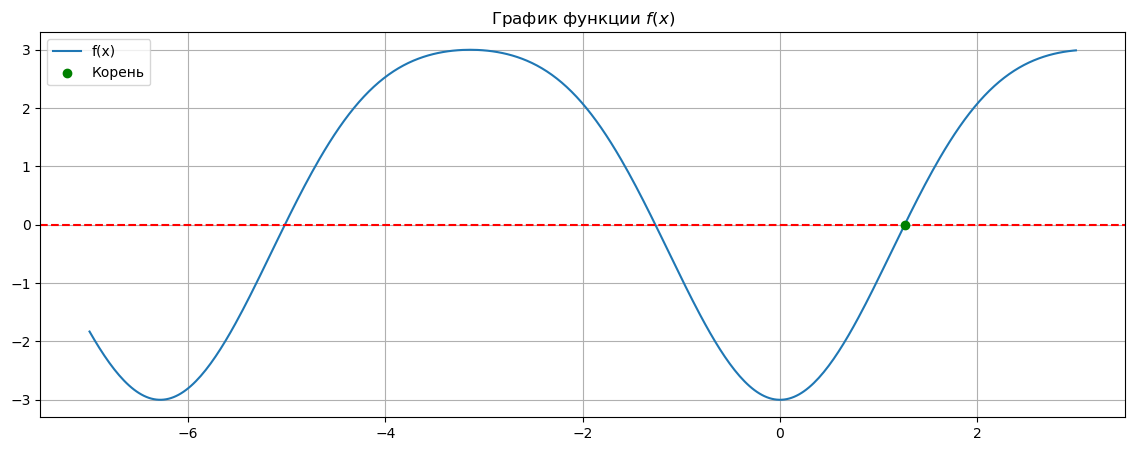

In [6]:
plt.figure(figsize=(14, 5))

x_plot = np.linspace(a, b, 400)
plt.plot(x_plot, f(x_plot), label='f(x)')
plt.axhline(0, color='red', linestyle='--')
plt.scatter([root], [f(root)], color='green', zorder=5, label='Корень')
plt.title("График функции $f(x)$")
plt.grid(True)
plt.legend()

График сходимости

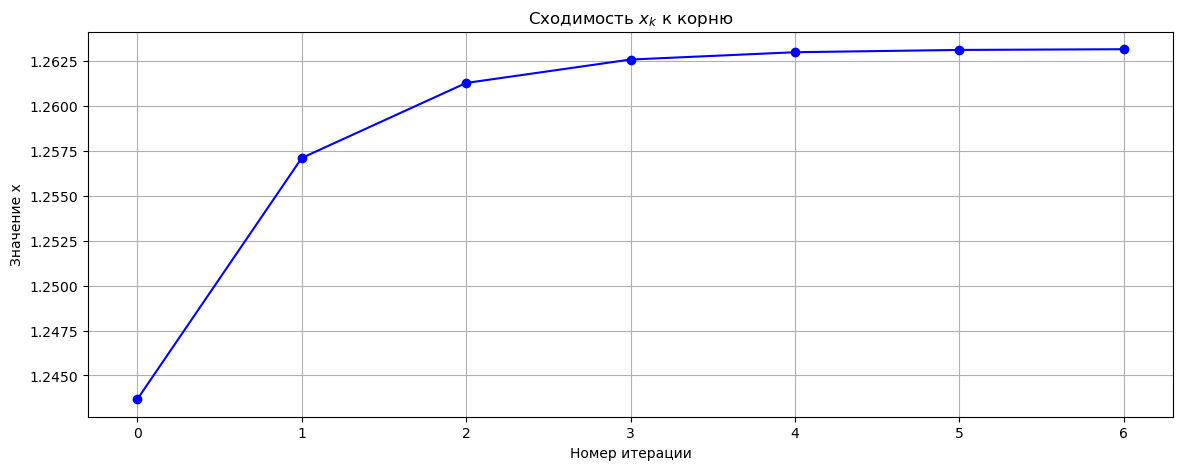

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(range(len(x_history)), x_history, 'bo-', label='$x_k$')
plt.title("Сходимость $x_k$ к корню")
plt.xlabel("Номер итерации")
plt.ylabel("Значение x")
plt.grid(True)